In [1]:
import numpy as np
import sounddevice as sd 
import lightkurve as lk
import matplotlib.pyplot as plt 

/Users/asmessier/miniconda3/envs/transitsong/lib/python3.11/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [113]:
# tic = 124029677 
# sector = 33

tic = "0001045298"
sector = 4

search_result = lk.search_lightcurve(
        f"TIC {tic}",
        mission="TESS",
        author="SPOC",
        sector =[sector]
    )

lc = search_result.download()


In [177]:
lc_binned = lc.bin(time_bin_size=0.01)

In [178]:
len(lc_binned)

2594

In [179]:
lc_fluxes = lc_binned.flux.value
lc_times = lc_binned.time.value


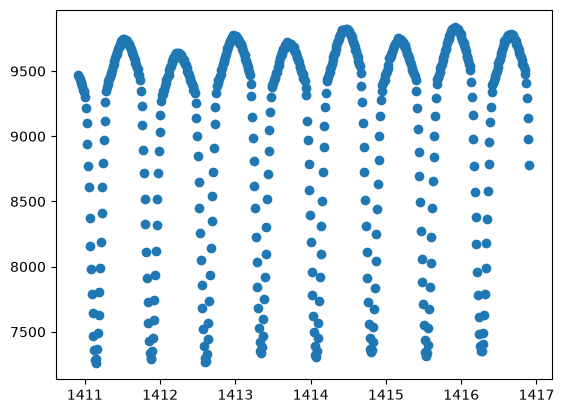

In [180]:
plt.scatter(lc_times[:600], lc_fluxes[:600])

In [181]:
len(lc_times)

2594

In [182]:
med_value = np.median(lc_fluxes)
lc_normflux = lc_fluxes/med_value

#central_val = 440 # hz 
max_val =900
min_val = 250

mapped_flux = (lc_normflux - np.min(lc_normflux)) / (np.max(lc_normflux) - np.min(lc_normflux)) * (max_val - min_val) + min_val

#plt.scatter(lc_times[1580:1650], mapped_flux[1580:1650])

In [183]:
# # for a loop
# freq_maps = ()

# samplerate = 4400
# duration = 0.05

# for flux in mapped_flux[:600]:
#     frequency = flux 
#     t = np.linspace(0, duration, int(samplerate * duration), endpoint=False)
    
#     audio_signal = 0.5 * np.sin(2*np.pi*frequency*t)

#     sd.play(audio_signal, samplerate)
#     sd.wait()


In [184]:
from scipy.io.wavfile import write

In [185]:
samplerate = 44100
duration = 0.05

med_value = np.median(lc_fluxes)
lc_normflux = lc_fluxes/med_value

#central_val = 440 # hz 
max_val = 400
min_val = 250

# normalize to frequencies 
mapped_flux = (lc_normflux - np.min(lc_normflux)) / (np.max(lc_normflux) - np.min(lc_normflux)) * (max_val - min_val) + min_val

audio = []
len_points = []

for flux in mapped_flux[:600]: #[:600]:
    frequency = flux 
    t = np.linspace(0, duration, int(samplerate * duration), endpoint=False)
    
    audio_signal = np.sin(2*np.pi*frequency*t)
    audio_signal = audio_signal[~np.isnan(audio_signal)]
    len_points.append(len(audio_signal))
    
    audio.extend(audio_signal)

audio_arr = np.array(audio)
    

In [186]:
sd.play(audio_arr, samplerate)
sd.wait()

KeyboardInterrupt: 

In [156]:
arr

array([-0.31762569, -0.92683708, -0.88801893, ...,         nan,
               nan,         nan], shape=(132000,))